In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('time_vs_score.csv')

x_train = data['Hours_Studied'].values # .values on any pandas series returns a NumPy ndarray 
y_train = data['Exam_Score'].values # array of exam score

print('Array of hours studied:', x_train)
print('Array of exam scores:', y_train)

Array of hours studied: [ 4.49 11.41  8.78  7.18  1.87  1.87  0.7  10.39  7.21  8.5   0.25 11.64
  9.99  2.55  2.18  2.2   3.65  6.3   5.18  3.49  7.34  1.67  3.51  4.4
  5.47  9.42  2.4   6.17  7.11  0.56  7.29  2.05  0.78 11.39 11.59  9.7
  3.66  1.17  8.21  5.28  1.46  5.94  0.41 10.91  3.11  7.95  3.74  6.24
  6.56  2.22 11.64  9.3  11.27 10.74  7.17 11.06  1.06  2.35  0.54  3.9
  4.66  3.26  9.94  4.28  3.37  6.51  1.69  9.63  0.89 11.84  9.27  2.38
  0.07  9.79  8.48  8.75  9.26  0.89  4.3   1.39 10.36  7.48  3.97  0.76
  3.73  3.9   8.76  7.65 10.65  5.67  1.44  8.56  9.13  6.74  9.25  5.93
  6.27  5.13  0.31  1.29  0.38  7.64  3.77  6.1  10.89  2.99  4.92  9.07
  2.75  0.92  3.48  1.93 11.16  9.7   7.6  10.46  9.64  2.24 10.71  6.47
  9.69 10.75  3.82  1.32  2.74  5.13  9.82 10.33  0.08  6.13  5.01  2.67
  1.44  4.05 11.31  3.88  6.23  8.44  4.36 11.66 11.55  3.02  5.97  3.61
  3.42  0.44  7.31  6.03  0.62  3.34 10.9   2.87  1.74  5.87 11.83  2.9
  8.07  9.14  2.85  8.74  4.41 

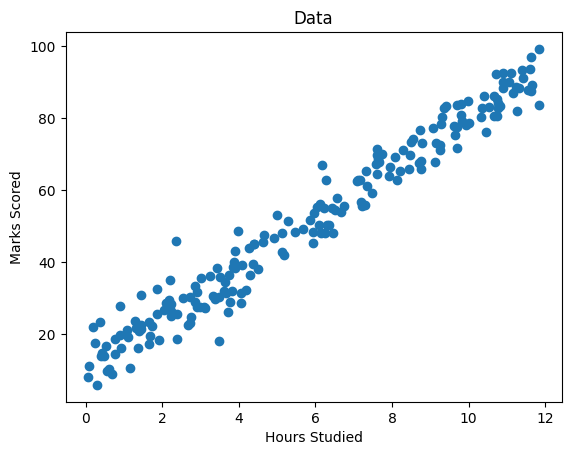

In [3]:
plt.scatter(x_train, y_train)
plt.title('Data')
plt.xlabel('Hours Studied')
plt.ylabel('Marks Scored')
plt.show()

In [4]:
def predict(x, m, c):
    y_predicted = m * x + c
    return y_predicted

print("For single x = 4.49:" , predict(4.49, 10, 5)) # return a single value
print("For the array x_train:", predict(x_train, 10, 5)) # returns an array of y_predicted wrt x_train

For single x = 4.49: 49.900000000000006
For the array x_train: [ 49.9 119.1  92.8  76.8  23.7  23.7  12.  108.9  77.1  90.    7.5 121.4
 104.9  30.5  26.8  27.   41.5  68.   56.8  39.9  78.4  21.7  40.1  49.
  59.7  99.2  29.   66.7  76.1  10.6  77.9  25.5  12.8 118.9 120.9 102.
  41.6  16.7  87.1  57.8  19.6  64.4   9.1 114.1  36.1  84.5  42.4  67.4
  70.6  27.2 121.4  98.  117.7 112.4  76.7 115.6  15.6  28.5  10.4  44.
  51.6  37.6 104.4  47.8  38.7  70.1  21.9 101.3  13.9 123.4  97.7  28.8
   5.7 102.9  89.8  92.5  97.6  13.9  48.   18.9 108.6  79.8  44.7  12.6
  42.3  44.   92.6  81.5 111.5  61.7  19.4  90.6  96.3  72.4  97.5  64.3
  67.7  56.3   8.1  17.9   8.8  81.4  42.7  66.  113.9  34.9  54.2  95.7
  32.5  14.2  39.8  24.3 116.6 102.   81.  109.6 101.4  27.4 112.1  69.7
 101.9 112.5  43.2  18.2  32.4  56.3 103.2 108.3   5.8  66.3  55.1  31.7
  19.4  45.5 118.1  43.8  67.3  89.4  48.6 121.6 120.5  35.2  64.7  41.1
  39.2   9.4  78.1  65.3  11.2  38.4 114.   33.7  22.4  63.7 123

In [5]:
def cost_function(y_train, x_train, m, c):
    
    n = len(y_train)
    
    errors = y_train - predict(x_train, m, c) # array of all the errors

    sq_errors = errors ** 2 # squared error array is in scientific notation
                            # numpy does this to represent numbers in a compact form
                    
    total_sq_error = np.sum(sq_errors)

    cost = total_sq_error / n
    
    return cost
    
cost = cost_function(y_train, x_train, 0, 0)
print(cost)

3228.5243455


In [6]:
def gradients(y_train, x_train, m, c):
    
    n = len(y_train)
    
    errors = y_train - predict(x_train, m, c)
    
    gradient_m = (-2 / n) * np.sum(errors * x_train)
    gradient_c = (-2 / n) * np.sum(errors)
    
    return gradient_m, gradient_c


In [7]:
def gradient_descent(y_train, x_train, m, c, learning_rate):
    
    gradient_m, gradient_c = gradients(y_train, x_train, m, c)
    
    m = m - learning_rate * gradient_m
    c = c - learning_rate * gradient_c

    return m, c


In [8]:
m = 0
c = 0
learning_rate = 0.01
epochs = 4000

for i in range(epochs):
    m, c = gradient_descent(y_train, x_train, m, c, learning_rate)
    
    if i % 200 == 0:
        print(f"Iteration: {i} Cost: {cost_function(y_train, x_train, m, c)}")
        

print(f'Final m: {m}, Final c: {c}')


Iteration: 0 Cost: 59.419738565594535
Iteration: 200 Cost: 26.22243897758804
Iteration: 400 Cost: 23.70103192834297
Iteration: 600 Cost: 23.401404641547725
Iteration: 800 Cost: 23.365798922503203
Iteration: 1000 Cost: 23.361567775059203
Iteration: 1200 Cost: 23.361064973566254
Iteration: 1400 Cost: 23.361005223972413
Iteration: 1600 Cost: 23.360998123727057
Iteration: 1800 Cost: 23.360997279981003
Iteration: 2000 Cost: 23.360997179715813
Iteration: 2200 Cost: 23.360997167800964
Iteration: 2400 Cost: 23.360997166385086
Iteration: 2600 Cost: 23.360997166216826
Iteration: 2800 Cost: 23.36099716619683
Iteration: 3000 Cost: 23.360997166194455
Iteration: 3200 Cost: 23.360997166194174
Iteration: 3400 Cost: 23.360997166194146
Iteration: 3600 Cost: 23.36099716619414
Iteration: 3800 Cost: 23.36099716619414
Final m: 6.9665538322361815, Final c: 10.530560357881154


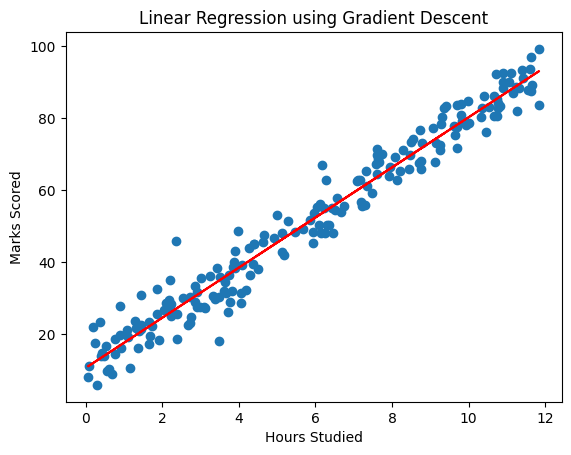

In [9]:
predictions = predict(x_train, m, c)

plt.scatter(x_train, y_train)
plt.plot(x_train, predictions, color = 'red')
plt.title("Linear Regression using Gradient Descent")
plt.xlabel("Hours Studied")
plt.ylabel("Marks Scored")
plt.show()

In [10]:
hours = float(input("How many houes did you study?: "))

predicted_marks = predict(hours, m, c)

print(f"Yours expected marks: {predicted_marks:.2f}")

Yours expected marks: 31.43
